<a href="https://colab.research.google.com/github/igorcavalcante/MVP_analise_exploratoria/blob/main/analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Igor Raphael Lins Cavalcante

**Matrícula:** 4052025001876

**Dataset:** [Kepler Objects of Interest (KOI)](https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=cumulative)

# Descrição do Problema 
O projeto aborda a dificuldade na validação de exoplanetas detectados pela sonda Kepler. Atualmente, a confirmação de um planeta exige intensa intervenção manual para separar sinais reais de falsos positivos (ruídos ou estrelas binárias), o que gera um atraso significativo no processo de descoberta científica.

O conjunto de dados KOI é uma lista gerada pela missão da sonda Kepler para identificar possíveis exoplanetas (Planetas fora do sistema solar). 

Os objetos podem ser classificados em:
 - Planetas candidatos (Ainda não há veredito sobre sua classificação)
 - Falsos positivos (Verificou-se que não eram planetas)
 - Exoplanetas confirmados

Em nossa abordagem vamos trabalhar somente com os falsos positivos e exoplanetas confirmados para deixar o modelo pronto para ser treinado por um modelo de classificação.

## Hipóteses do Problema

1. Existe um limiar de raio acima do qual o número de planetas confirmados cai drasticamente

2. A profundidade do trânsito impacta a classificação do objeto

3. Existe um 'limite térmico' acima do qual a probabilidade de um objeto ser classificado como Falso Positivo aumenta drasticamente

## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado o conjunto de características do dataset, o objetivo é identificar se o objeto é um exoplaneta confirmado ou um falso positivo.

## Seleção de Dados

O dataset KOI possui uma variedade enorme de atributos e será utilizado somente um subconjunto dos mesmos. Uma versão do dataset se encontra localmente no diretório **data** do repositório.

## Atributos do Dataset

**TODO**: O dataset contém 7326 amostras. Possui dez atributos:

- koi_disposition: Classificação oficial (Confirmado ou Falso Positivo)
- koi_model_snr: A relação sinal-ruído. Sinais fracos têm mais chance de serem ruído instrumental

### Atributos planetários
- koi_period: O tempo que o planeta leva para orbitar a estrela. (dias) 
- koi_prad: O raio planetário calculado (Raios terrestres)
- koi_teq: Temperatura de equilíbrio do candidato (K)
- koi_duration: Duração do trânsito (horas)
- koi_insol: Fluxo de radiação incidente (insolação) \[fluxo terrestre]


### Atributos estelares
- koi_depth: O quanto a luz da estrela "cai" no momento do trânsito (em partes por milhão).
- koi_slogg: Gravidade superficial da estrela \[log(cm/s²)]
- koi_steff: Temperatura efetiva da estrela hospedeira. (K)

# Importação das Bibliotecas Necessárias e Carga de Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# carregamento do dataset
koi = pd.read_csv("https://raw.githubusercontent.com/igorcavalcante/MVP_analise_exploratoria/refs/heads/main/data/cumulative_2026.03.26_10.36.47.csv")

In [3]:
# selecionando somente as colunas necessárias para o estudo
atributos = [
    'koi_disposition', 'koi_model_snr', 
    'koi_period', 'koi_prad', 'koi_teq', 'koi_duration', 'koi_insol',
    'koi_depth', 'koi_slogg', 'koi_steff'
]

df = koi[atributos]

In [4]:
# precisaremos somente das linhas cujo koi_disposition é CONFIRMED ou FALSE POSITIVE
df = df[(df['koi_disposition'] == 'CONFIRMED') | (df['koi_disposition'] == 'FALSE POSITIVE')]

In [5]:
# primeiras linhas
df.head()

,koi_disposition,koi_model_snr,koi_period,koi_prad,koi_teq,koi_duration,koi_insol,koi_depth,koi_slogg,koi_steff
0,CONFIRMED,35.8,9.488036,2.26,793.0,2.95750,93.59,615.8,4.467,5455.0
1,CONFIRMED,25.8,54.418383,2.83,443.0,4.50700,9.11,874.8,4.467,5455.0
3,FALSE POSITIVE,505.6,1.736952,33.46,1395.0,2.40641,891.96,8079.2,4.564,5805.0
4,CONFIRMED,40.9,2.525592,2.75,1406.0,1.65450,926.16,603.3,4.438,6031.0
5,CONFIRMED,66.5,11.094321,3.90,835.0,4.59450,114.81,1517.5,4.486,6046.0


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset KOI, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset KOI possui 7585 instâncias (observações), é desbalanceado, com 2746 instâncias para CONFIRMED e
4839 para FALSE POSITIVE. As nove características de medição são de tipo numérico (float), enquanto o atributo 'koi_disposition' é categórico.

In [6]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())
print("\n Distribuição dos dados de acordo com as duas categorias")
print(df.groupby('koi_disposition').size())

Total de instâncias: 7585

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
Index: 7585 entries, 0 to 9563
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   koi_disposition  7585 non-null   object 
 1   koi_model_snr    7326 non-null   float64
 2   koi_period       7585 non-null   float64
 3   koi_prad         7326 non-null   float64
 4   koi_teq          7326 non-null   float64
 5   koi_duration     7585 non-null   float64
 6   koi_insol        7366 non-null   float64
 7   koi_depth        7326 non-null   float64
 8   koi_slogg        7326 non-null   float64
 9   koi_steff        7326 non-null   float64
dtypes: float64(9), object(1)
memory usage: 651.8+ KB
None

 Distribuição dos dados de acordo com as duas categorias
koi_disposition
CONFIRMED         2746
FALSE POSITIVE    4839
dtype: int64


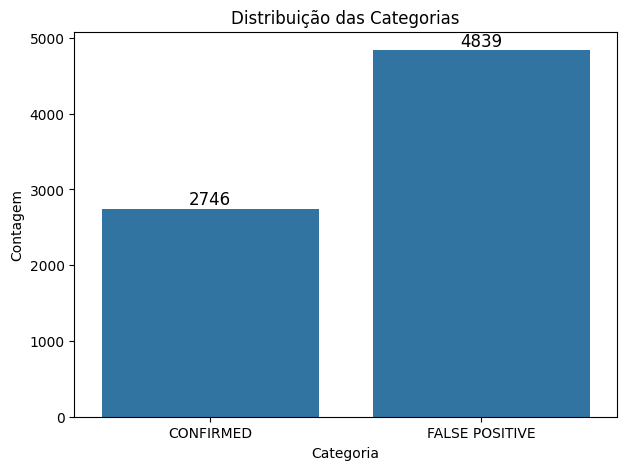

In [7]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='koi_disposition', data=df  )
ax.bar_label(ax.containers[0], fontsize=12)
plt.title('Distribuição das Categorias')
plt.xlabel('Categoria')
plt.ylabel('Contagem')
plt.show()

O gráfico de barras mostra a quantidade de amostras em cada categoria do dataset reforçando que o mesmo é desbalanceado.

## Tratando os valores nulos

In [8]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos:")
print(df.isnull().sum())
# Eliminando os valores nulos
df = df.dropna(subset=['koi_model_snr', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_depth', 'koi_slogg', 'koi_steff'])
# confirmando a eliminação
print("\nValores nulos após tratamento:")
print(df.isnull().sum())

Valores nulos:
koi_disposition      0
koi_model_snr      259
koi_period           0
koi_prad           259
koi_teq            259
koi_duration         0
koi_insol          219
koi_depth          259
koi_slogg          259
koi_steff          259
dtype: int64

Valores nulos após tratamento:
koi_disposition    0
koi_model_snr      0
koi_period         0
koi_prad           0
koi_teq            0
koi_duration       0
koi_insol          0
koi_depth          0
koi_slogg          0
koi_steff          0
dtype: int64


## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [9]:
# estatísticas descritivas básicas do dataset
df.describe()

,koi_model_snr,koi_period,koi_prad,koi_teq,koi_duration,koi_insol,koi_depth,koi_slogg,koi_steff
count,7326.000000,7326.000000,7326.000000,7326.000000,7326.000000,7.326000e+03,7.326000e+03,7326.000000,7326.000000
mean,318.594049,49.809608,104.169379,1154.306306,5.741686,9.362607e+03,2.952961e+04,4.310837,5715.973928
std,881.096351,110.586443,3180.483497,900.618618,6.843512,1.786470e+05,9.117009e+04,0.437200,819.235213
min,0.000000,0.241843,0.080000,92.000000,0.104600,2.000000e-02,8.000000e-01,0.047000,2661.000000
25%,15.400000,2.217017,1.500000,581.000000,2.492325,2.692750e+01,1.826500e+02,4.218000,5313.000000
50%,30.500000,7.802656,2.620000,933.000000,3.863000,1.790900e+02,5.015000e+02,4.438000,5774.000000
75%,114.775000,27.938684,24.185000,1481.750000,6.282250,1.138612e+03,2.319050e+03,4.543000,6116.750000
max,9054.700000,1071.232624,200346.000000,14667.000000,138.540000,1.094755e+07,1.541400e+06,5.283000,15896.000000


Percebe-se uma diferença muito grande entre os valores mínimos, máximos e os quartis da maioria das colunas. Vamos realizar um tratamento destes dados em seguida.

## Aplicando uma transformação logarítmica
Uma vez que estamos lidando com valores literalmente astronômicos com uma variação muito grande, os dados ficam mais fáceis de serem analisados quando aplicamos uma transformação logarítmica em seus atributos.
Alguns atributos como steff e slogg não vão sofrer esta transformação.

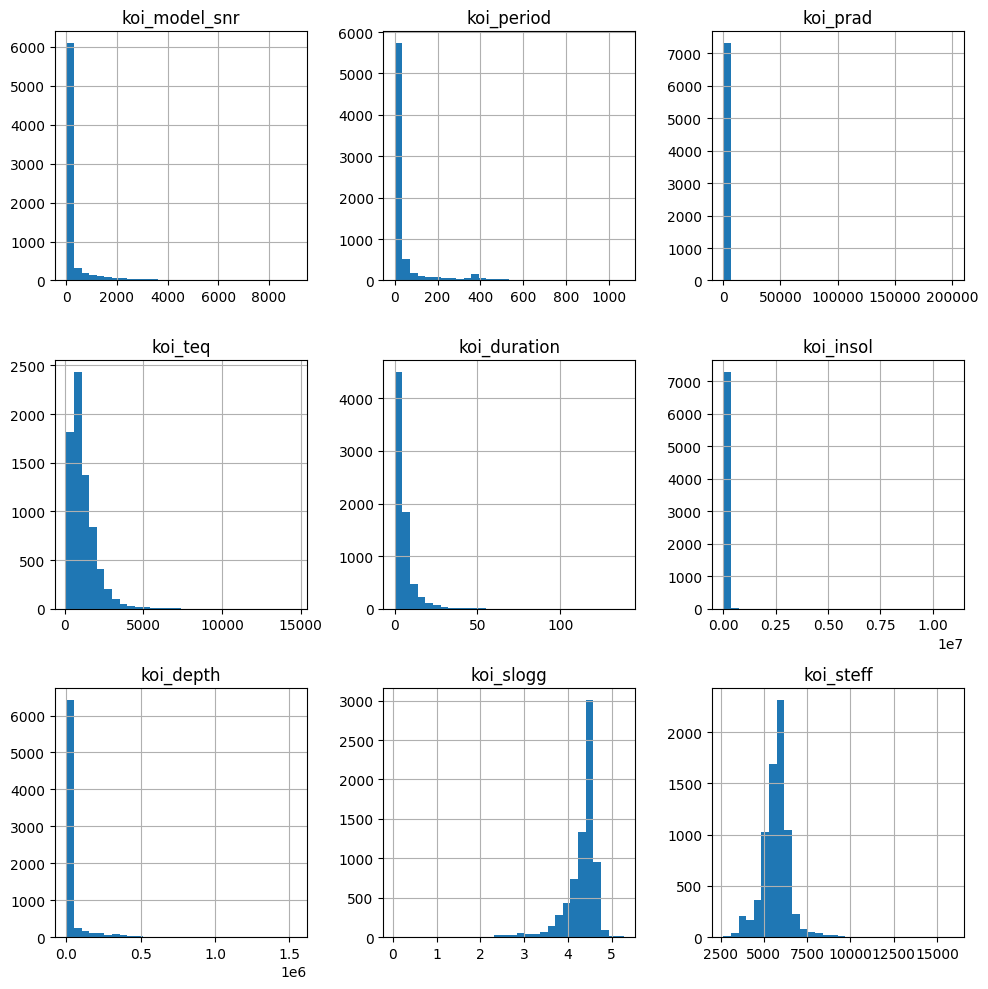

In [10]:
# Vamos mostrar o histograma dos atributos antes do tratamento
df.hist(figsize=(10, 10), bins=30)
plt.tight_layout()
plt.show()

In [11]:
# Lista de atributos que variam em ordens de magnitude
cols_log = ['koi_model_snr', 'koi_period', 'koi_prad', 'koi_insol', 'koi_depth']

# Aplicando a transformação
for col in cols_log:
    df[col] = np.log1p(df[col])


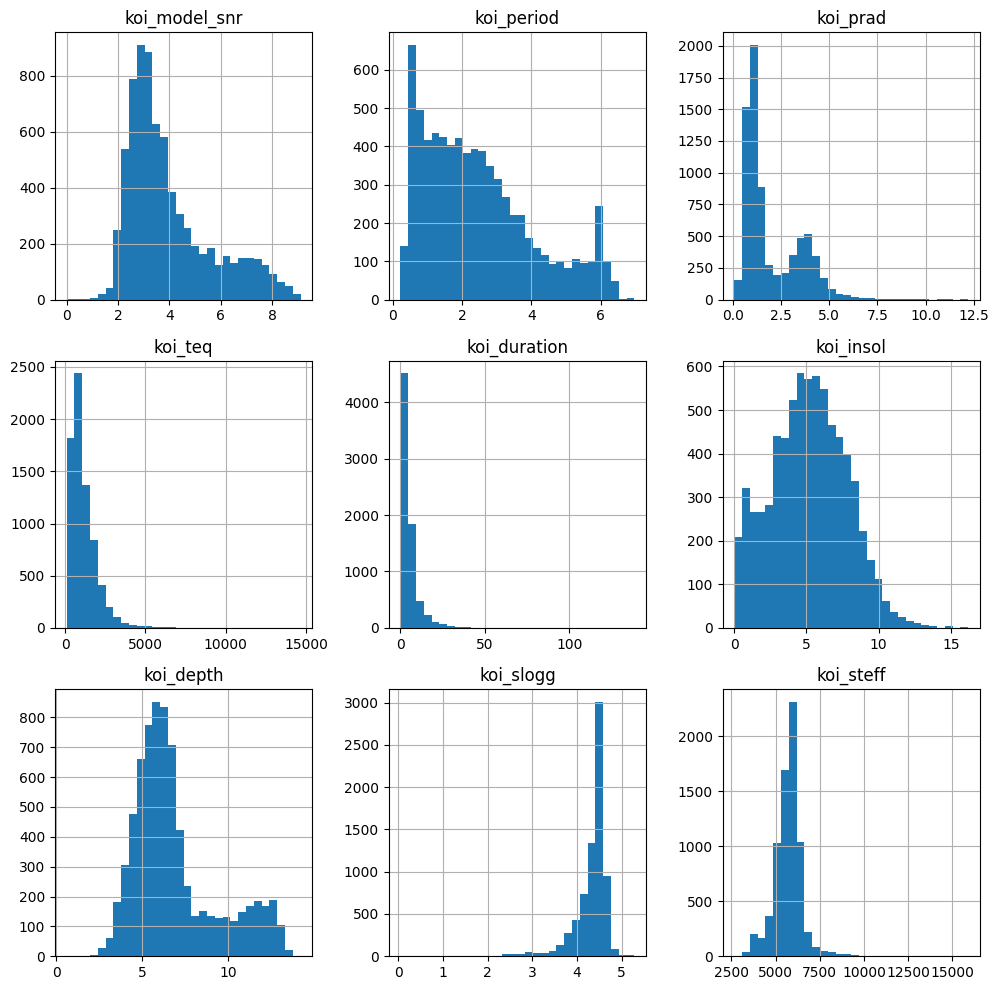

In [12]:
# Verificando os histogramas após a aplicação
df.hist(figsize=(10, 10), bins=30)
plt.tight_layout()
plt.show()

### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [13]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

koi_model_snr       3.983974
koi_period          2.471468
koi_prad            1.987697
koi_teq          1154.306306
koi_duration        5.741686
koi_insol           5.193496
koi_depth           6.901730
koi_slogg           4.310837
koi_steff        5715.973928
Name: mean, dtype: float64

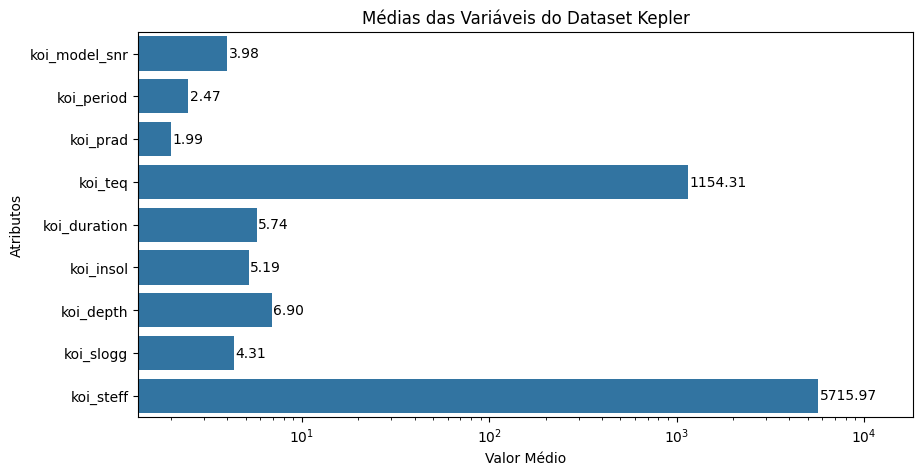

In [14]:
# Exibindo gráficamente as médias. Foi utilizada uma escala logarítmica para acomodar melhor os diferentes valores
medias = df.describe().loc['mean']

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=medias.values, y=medias.index, legend=False)

ax.bar_label(ax.containers[0], padding=1, fmt='%.2f')
ax.set_xscale('log')

x_limit = ax.get_xlim()
ax.set_xlim(x_limit[0], x_limit[1] * 2.15)

plt.title('Médias das Variáveis do Dataset Kepler')
plt.xlabel('Valor Médio')
plt.ylabel('Atributos')
plt.show()

Percebe-se uma média elevada em dois dos atributos que não houve aplicação da função logarítmica.

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [15]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']

koi_model_snr      1.652827
koi_period         1.586939
koi_prad           1.450080
koi_teq          900.618618
koi_duration       6.843512
koi_insol          2.603139
koi_depth          2.488265
koi_slogg          0.437200
koi_steff        819.235213
Name: std, dtype: float64

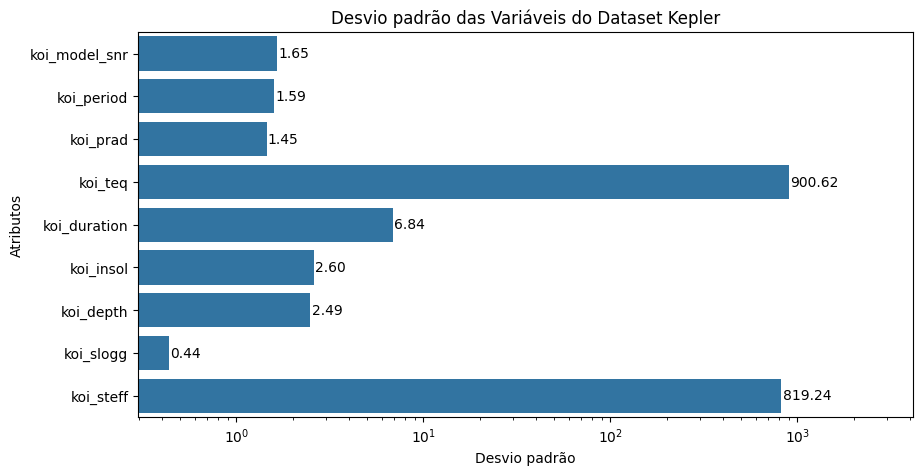

In [16]:
# Exibindo gráficamente o desvio padrão do dataset. Foi utilizada uma escala logarítmica para acomodar melhor os valores
stds = df.describe().loc['std']

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=stds.values, y=stds.index, legend=False)

ax.bar_label(ax.containers[0], padding=1, fmt='%.2f')
ax.set_xscale('log')

x_limit = ax.get_xlim()
ax.set_xlim(x_limit[0], x_limit[1] * 3.15)

plt.title('Desvio padrão das Variáveis do Dataset Kepler')
plt.xlabel('Desvio padrão')
plt.ylabel('Atributos')
plt.show()

Percebe-se um desvio padrão alto justamente em dois dos atributos em que a transformação logarítmica não foi aplicada.

## Histograma
Uma vez que os dados estão numa escala mais adequada, podemos seguir com os histogramas.

### Relação Sinal Ruído da amostra (koi_model_snr)
Observa-se que há poucos planetas confirmados com **Relação Sinal-Ruído** baixa, pois ou são flutuações estatísticas ou objetos muito pequenos difíceis de serem confirmados.

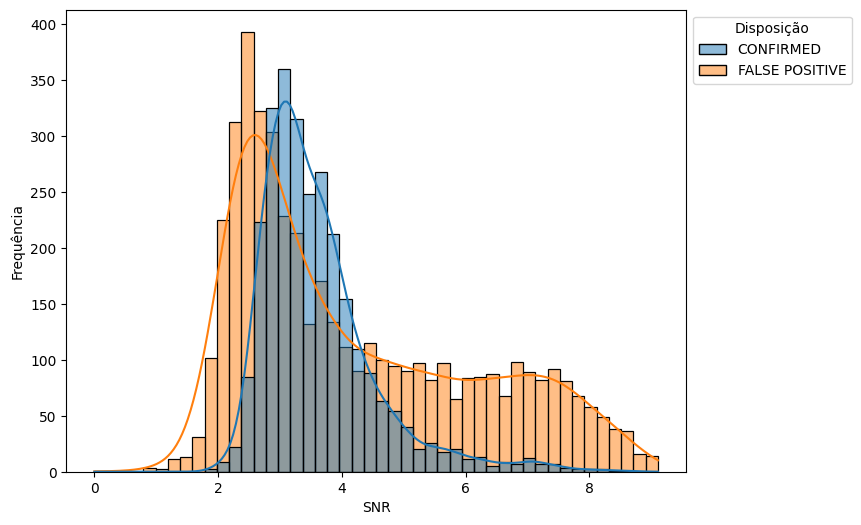

In [17]:
plt.figure(figsize=(8, 6))
ax = sns.histplot(data=df, x='koi_model_snr', kde=True, hue='koi_disposition')
plt.xlabel('SNR')
plt.ylabel('Frequência')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Disposição')
plt.show()

### Período Orbital (koi_period)

Percebe-se que os planetas confirmados se concentram mais na região central do gráfico.

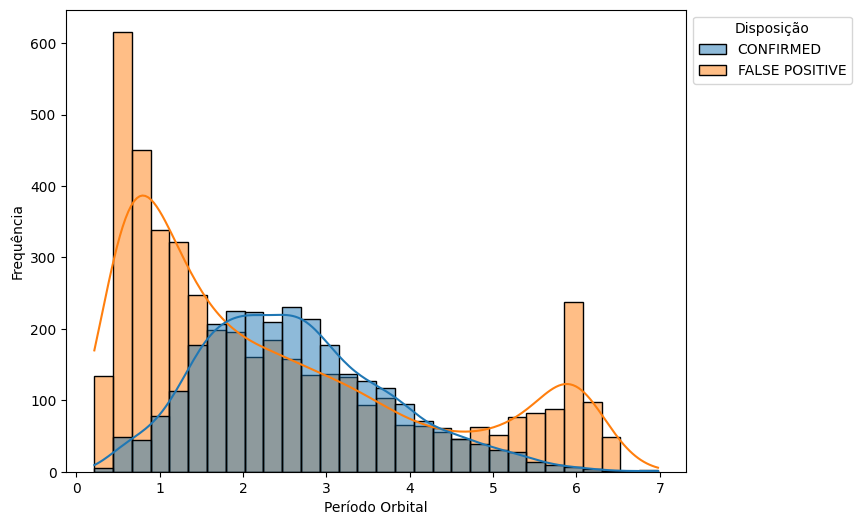

In [18]:
plt.figure(figsize=(8, 6))
ax = sns.histplot(data=df, x='koi_period', hue='koi_disposition', kde=True)
plt.xlabel('Período Orbital')
plt.ylabel('Frequência')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Disposição')

plt.show()

### Raio da amostra (koi_prad)
Existe uma concentração de planetas confirmados em determinada faixa de tamanhos de raio, o que reforça a hipótese número 1.

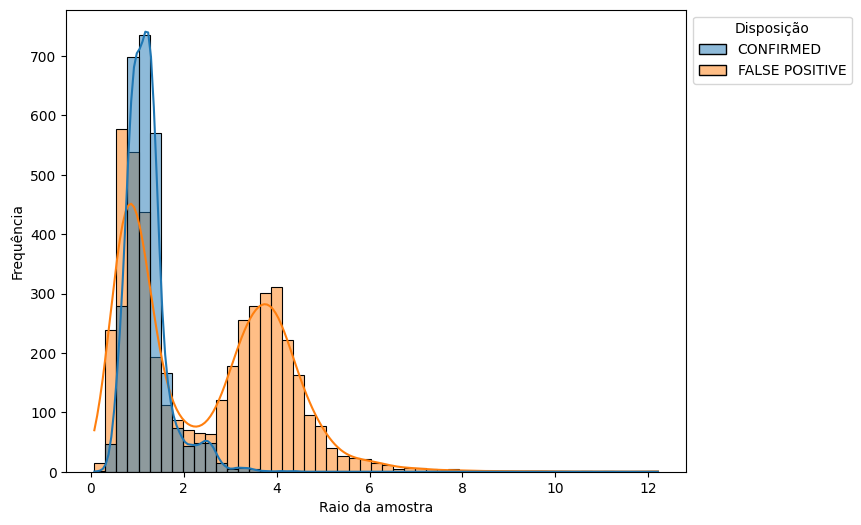

In [19]:
plt.figure(figsize=(8, 6))
ax = sns.histplot(data=df, x='koi_prad', hue='koi_disposition', kde=True)
plt.xlabel('Raio da amostra')
plt.ylabel('Frequência')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Disposição')

plt.show()

### Temperatura de equilíbrio (koi_teq)
Percebe-se que a maior parte dos 
**planetas confirmados** estão até 2000 Kelvin e que objetos mais quentes tendem a ser **falsos positivos**. Possivelmente estrelas compondo sistemas binários. Isto reforça nossa hipótese número 3.

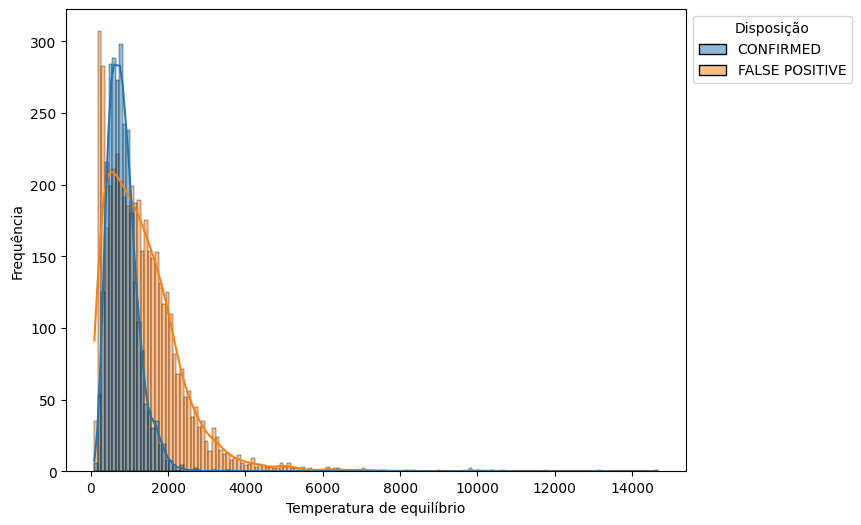

In [20]:
plt.figure(figsize=(8, 6))
ax = sns.histplot(data=df, x='koi_teq', kde=True, hue='koi_disposition')
plt.xlabel('Temperatura de equilíbrio')
plt.ylabel('Frequência')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Disposição')

plt.show()

### Duração do Trânsito (koi_duration)
A maioria dos dados se concentram no começo da escala, até 20 horas.

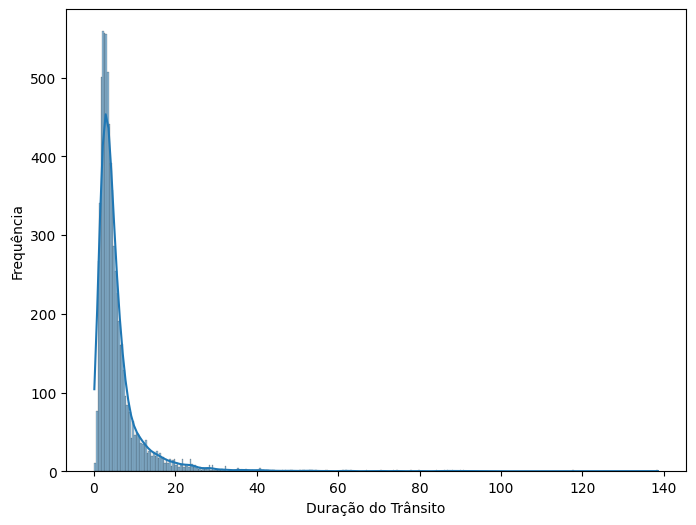

In [21]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='koi_duration', kde=True)
plt.xlabel('Duração do Trânsito')
plt.ylabel('Frequência')

plt.show()

### Profundidade do Trânsito (koi_depth)
Nota-se que os objetos confirmados encontram-se em uma região bem específica do histograma.
Isto reforça a hipótese número 2.

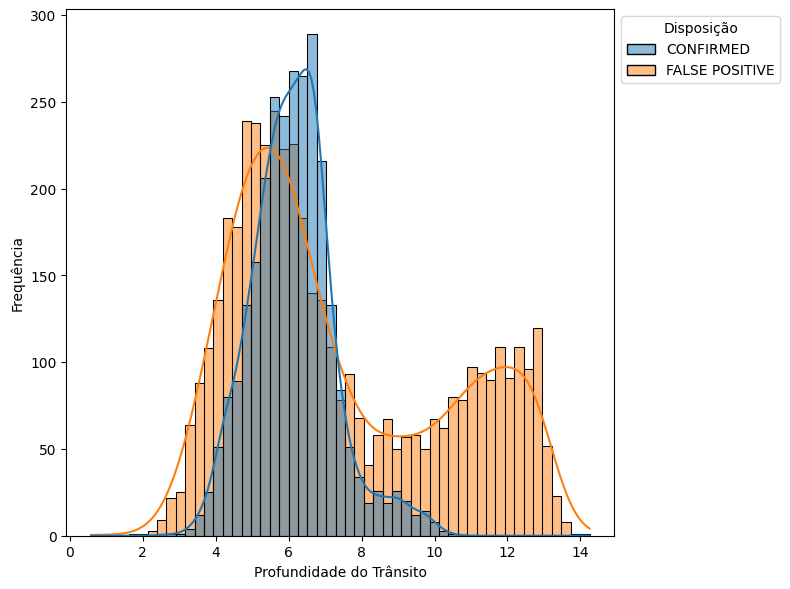

In [22]:
plt.figure(figsize=(8, 6))
ax = sns.histplot(data=df, x='koi_depth', kde=True, hue='koi_disposition')
plt.xlabel('Profundidade do Trânsito')
plt.ylabel('Frequência')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Disposição')

plt.tight_layout()
plt.show()

### Gravidade superficial da estrela (koi_slogg)
Os valores estão bem concentrados no canto direito do gráfico.

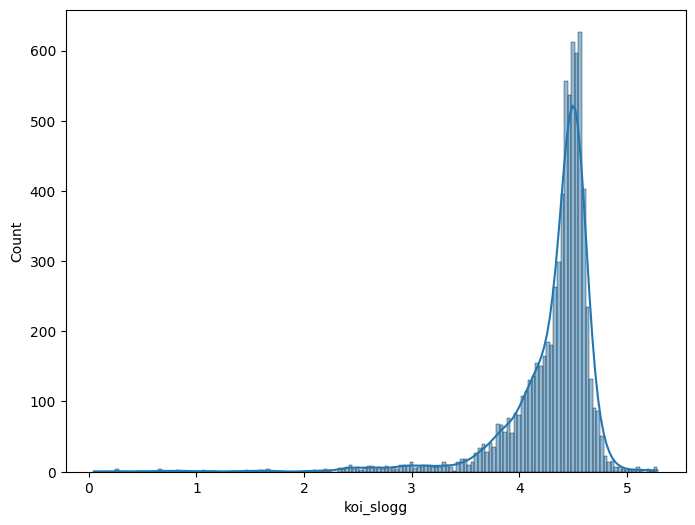

In [23]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='koi_slogg', kde=True)

plt.show()

### Temperatura efetiva da estrela (koi_steff)
Estão bem distribuídas em torno dos 6000 K.

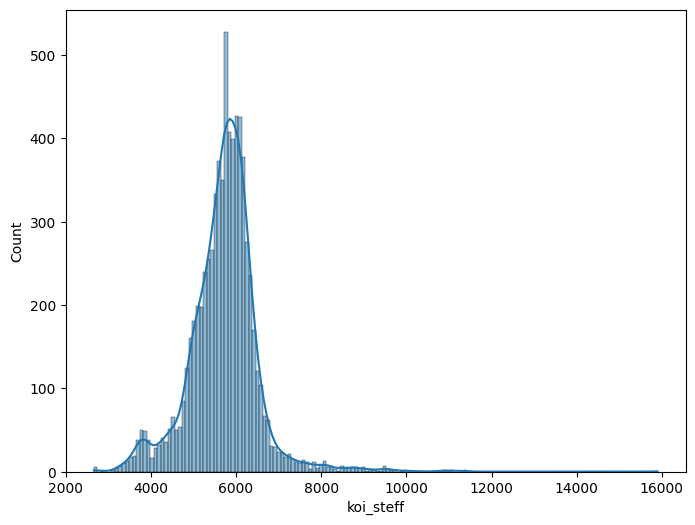

In [24]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='koi_steff', kde=True)

plt.show()

## Boxplot

Para entender as diferenças entre as classificações devemos olhar como se comportam os valores quando agrupados pelo **koi_disposition**. Isso nos permite comparar a média, mediana e desvio padrão de cada característica para os **falsos positivos** e os **planetas confirmados**, além de visualizar suas distribuições por meio de boxplots.


In [25]:
df.groupby('koi_disposition').describe()

koi_model_snr                                         \
                        count      mean       std       min      25%   
koi_disposition                                                        
CONFIRMED              2744.0  3.601388  0.912643  1.931521  2.98946   
FALSE POSITIVE         4582.0  4.213092  1.931135  0.000000  2.61007   

                                              koi_period            ...  \
                      50%       75%       max      count      mean  ...   
koi_disposition                                                     ...   
CONFIRMED        3.387774  3.951724  8.690625     2744.0  2.628182  ...   
FALSE POSITIVE   3.562465  5.687822  9.111150     4582.0  2.377617  ...   

                koi_slogg        koi_steff                                   \
                      75%    max     count         mean         std     min   
koi_disposition                                                               
CONFIRMED           4.557  5.274    2744.0  5480.472668  670.668904  2703.0   
FALSE POSITIVE      4.534  5.283    4582.0  5857.007420  866.438910  2661.0   

                                                   
                     25%     50%     75%      max  
koi_disposition                                    
CONFIRMED        5166.50  5616.5  5929.0   9565.0  
FALSE POSITIVE   5407.25  5867.0  6227.0  15896.0  

[2 rows x 72 columns]

### **Raio planetário calculado (koi_prad)** por Classificação


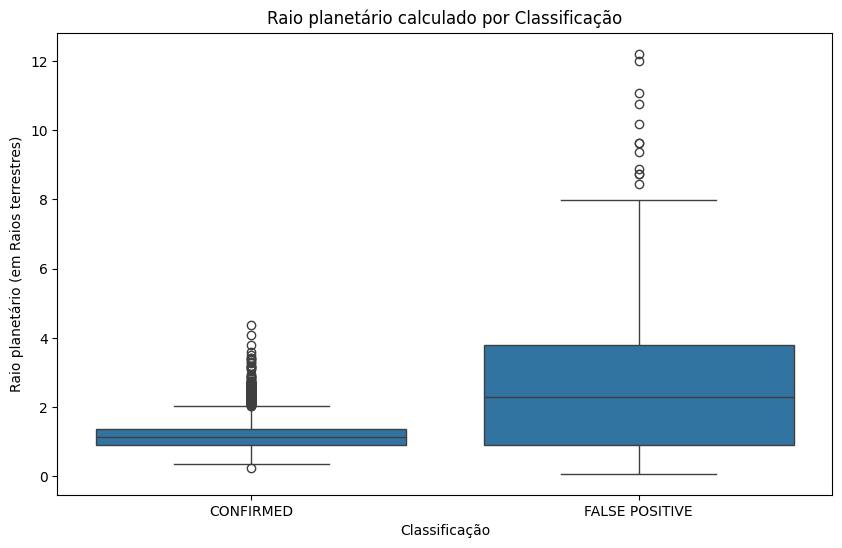

In [26]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='koi_disposition', y='koi_prad', data=df)
plt.title('Raio planetário calculado por Classificação')
plt.xlabel('Classificação')
plt.ylabel('Raio planetário (em Raios terrestres)')
plt.show()

O boxplot do **raio planetário por classificação** demonstra que os **planetas confirmados** possuem valores muito mais estreitos que os **falsos positivos**. Há uma sobreposição entre os valores confirmados, mas as medianas e as caixas indicam uma distinção. Estas observações dão mais força à hipótese número 1.

É importante salientar a quantidade outliers identificados na parte superior do boxplot devido a natureza astronômica dos dados.

 ### **Profundidade de trânsito (koi_depth)** pela Classificação

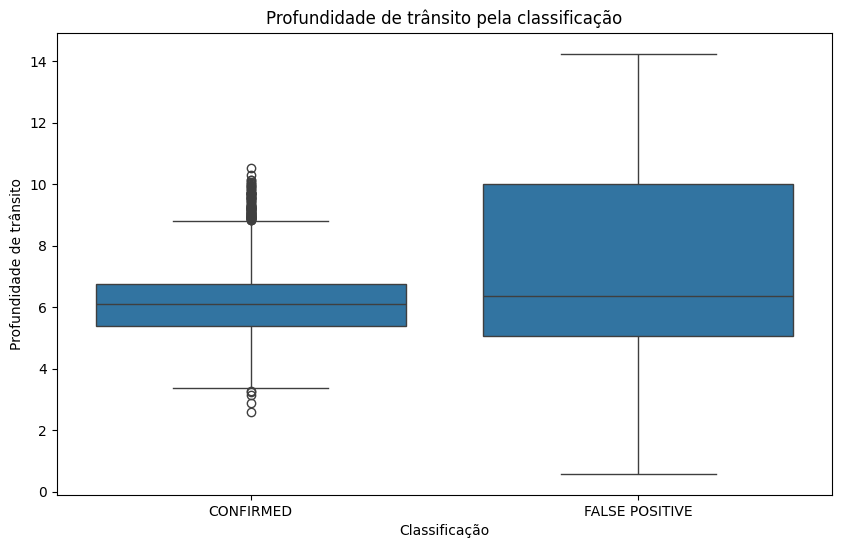

In [27]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='koi_disposition', y='koi_depth', data=df)
plt.title('Profundidade de trânsito pela classificação')
plt.xlabel('Classificação')
plt.ylabel('Profundidade de trânsito')
plt.show()

O boxplot da **profundidade de trânsito pela classificação** demonstra que os **planetas confirmados** possuem valores muito mais estreitos que os **falsos positivos**. Os **planetas confirmados** também demonstram vários outliers, principalmente no trecho superior do boxplot. A distinção clara entre os dois boxplots reforça a hipótese número 2.

### **Temperatura de equilíbrio (koi_teq)** pela classificação

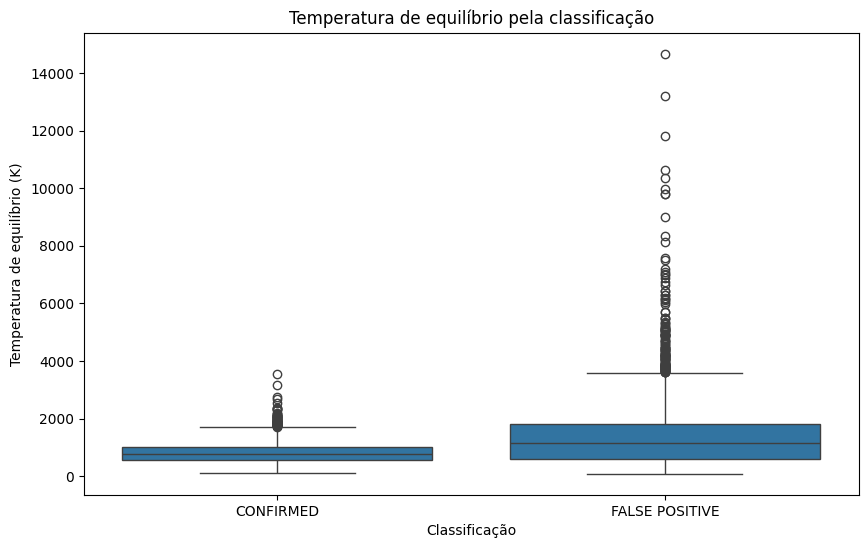

In [28]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='koi_disposition', y='koi_teq', data=df)
plt.title('Temperatura de equilíbrio pela classificação')
plt.xlabel('Classificação')
plt.ylabel('Temperatura de equilíbrio (K)')
plt.show()

Os dois boxplots são bem distintos. Enquanto os **planetas confirmados** são bem mais estreitos e com outliers até 4000K, os **falsos positivos** possuem um boxplot que é mais longo e que os outliers da parte superior vão até a faixa dos 14000K. Esta disposição de dados reforça bastante a hipótese número 3.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das amostras podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [29]:
# Matriz de correlação
print("\nMatriz de Correlação:")
df_corr = df.drop('koi_disposition', axis=1).corr()
df_corr


Matriz de Correlação:


,koi_model_snr,koi_period,koi_prad,koi_teq,koi_duration,koi_insol,koi_depth,koi_slogg,koi_steff
koi_model_snr,1.000000,-0.139564,0.701006,0.074334,0.102090,0.139244,0.860747,-0.027334,0.127349
koi_period,-0.139564,1.000000,-0.017776,-0.652732,0.379655,-0.861115,0.066632,-0.016413,-0.018044
koi_prad,0.701006,-0.017776,1.000000,0.221990,0.169827,0.192256,0.772138,-0.363432,0.165018
koi_teq,0.074334,-0.652732,0.221990,1.000000,-0.187348,0.886214,-0.091602,-0.566774,0.248098
koi_duration,0.102090,0.379655,0.169827,-0.187348,1.000000,-0.253630,0.096333,-0.122219,0.097480
koi_insol,0.139244,-0.861115,0.192256,0.886214,-0.253630,1.000000,-0.082417,-0.414386,0.303810
koi_depth,0.860747,0.066632,0.772138,-0.091602,0.096333,-0.082417,1.000000,0.036130,0.027701
koi_slogg,-0.027334,-0.016413,-0.363432,-0.566774,-0.122219,-0.414386,0.036130,1.000000,-0.139186
koi_steff,0.127349,-0.018044,0.165018,0.248098,0.097480,0.303810,0.027701,-0.139186,1.000000


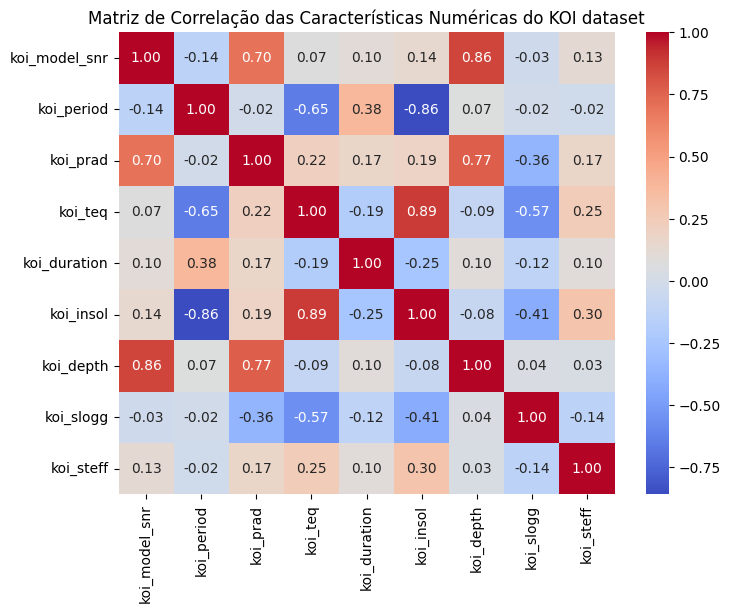

In [30]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do KOI dataset')
plt.show()

O mapa de calor da matriz de correlação revela fortes correlações positivas entre *koi_insol* e *koi_teq*, *koi_depth* e *koi_model_snr*, bem como *koi_depth* e *koi_prad*. Já como correlação negativa forte temos *koi_insol* e *koi_period*. Isso sugere que essas características têm relações fortes, o que é útil para a seleção de características.

# Scatter plot
Uma vez exibida a matriz de correlação vamos exibir as correlações interessantes em gráficos de dispersão.

### Relação entre Fluxo de insolação (koi_insol) e Temperatura de Equilíbrio (koi_teq)

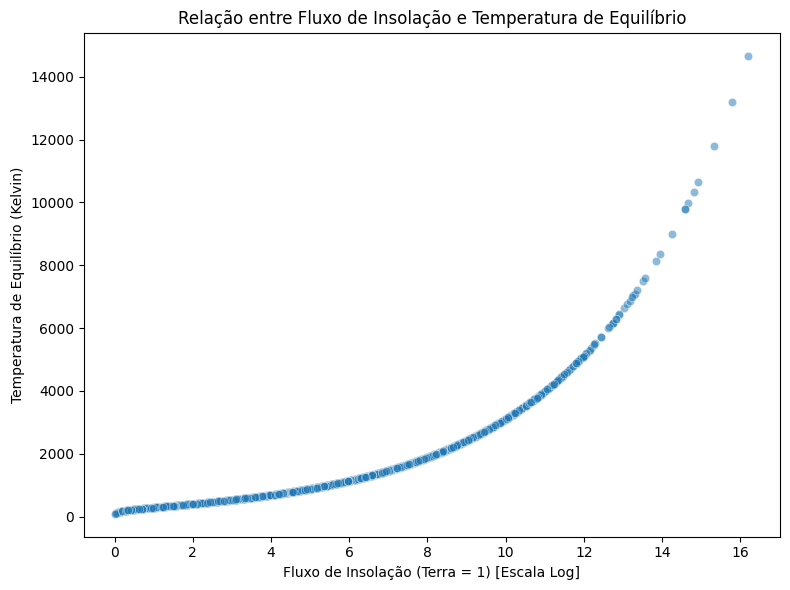

In [31]:
plt.figure(figsize=(8, 6))

ax = sns.scatterplot(data=df, x='koi_insol', y='koi_teq', alpha=0.5)

plt.title('Relação entre Fluxo de Insolação e Temperatura de Equilíbrio')
plt.xlabel('Fluxo de Insolação (Terra = 1) [Escala Log]')
plt.ylabel('Temperatura de Equilíbrio (Kelvin)')

plt.tight_layout()
plt.show()

Conseguimos perceber uma relação interessante entre a quantidade de insolação que o planeta recebe e sua temperatura de equilíbrio, o que faz todo sentido. Importante notar a forma do gráfico, já que o eixo X sofreu uma transformação logarítmica

### Profundidadade de trânsito (koi_depth) e Relação sinal ruído (koi_snr)

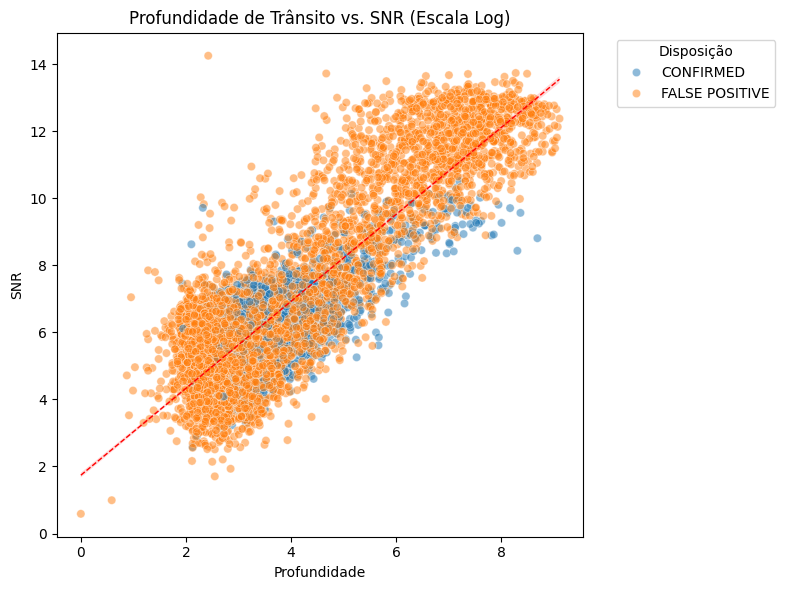

In [32]:
plt.figure(figsize=(8, 6))

ax = sns.scatterplot(data=df, x='koi_model_snr', y='koi_depth', alpha=0.5, hue='koi_disposition')

sns.regplot(
    data=df,
    x='koi_model_snr', 
    y='koi_depth', 
    scatter=False, 
    color='red', 
    line_kws={'linestyle': '--', 'linewidth': 1}
)

plt.title('Profundidade de Trânsito vs. SNR (Escala Log)')
plt.xlabel('Profundidade')
plt.ylabel('SNR')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Disposição')

plt.tight_layout()
plt.show()

Uma vez que os dois atributos sofreram transformações logarítmicas podemos ver o gráfico numa disposição mais linear. Sobrepomos o gráfico com uma linha de regressão para ilustrar melhor a relação entre estes dois atributos. É importante notar como a qualidade do Sinal sofre impacto com a profundidade da queda do brilho causada pelo trânsito do objeto que passa pela estrela hospedeira.

### Profundidade do Trânsito (koi_depth) vs Raio Planetário (koi_prad)

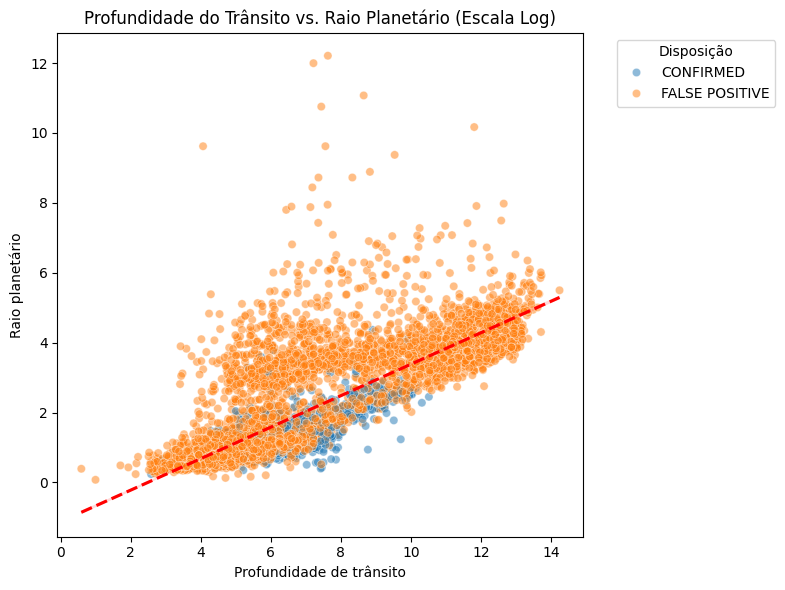

In [33]:
plt.figure(figsize=(8, 6))

ax = sns.scatterplot(
    data=df, 
    x='koi_depth', 
    y='koi_prad', 
    hue='koi_disposition', 
    alpha=0.5, 
)

sns.regplot(
    data=df, 
    x='koi_depth', 
    y='koi_prad', 
    scatter=False, 
    color='red', 
    line_kws={'linestyle': '--'}
)

plt.title('Profundidade do Trânsito vs. Raio Planetário (Escala Log)')
plt.xlabel('Profundidade de trânsito')
plt.ylabel('Raio planetário')
plt.legend(title='Disposição', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

O gráfico de dispersão acima demonstra uma característica bem interessante. Quanto maior o raio da amostra, maior o impacto que ele vai ter na curva de luz da estrela hospedeira quando o mesmo estiver passando na frente da estrela.

### Período do trânsito (koi_period) vs. Insolação (koi_insol)

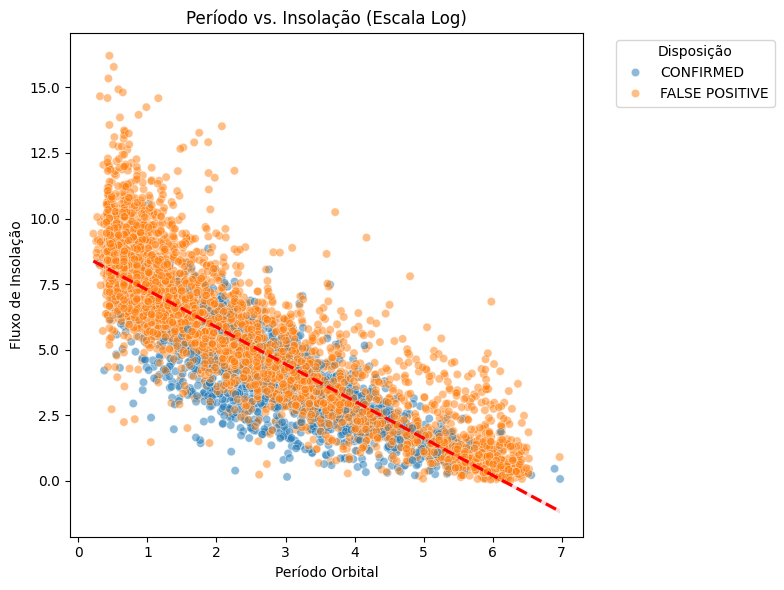

In [34]:
plt.figure(figsize=(8, 6))

ax = sns.scatterplot(
    data=df, 
    x='koi_period', 
    y='koi_insol', 
    hue='koi_disposition', 
    alpha=0.5,
)

sns.regplot(
    data=df, 
    x='koi_period', 
    y='koi_insol', 
    scatter=False, 
    color='red', 
    line_kws={'linestyle': '--'}
)

plt.title('Período vs. Insolação (Escala Log)')
plt.xlabel('Período Orbital')
plt.ylabel('Fluxo de Insolação')
plt.legend(title='Disposição', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Este gráfico explica que quanto maior o período orbital, menor o fluxo de insolação que o mesmo recebe.
O que faz total sentido com a Terceira Lei de Kepler que estabelece:

> Quanto mais distante estivermos do Sol, mais tempo levaremos para completar uma volta ao seu redor.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [35]:
# Separar features (X) e target (y)
X = df.drop('koi_disposition', axis=1)
y = df['koi_disposition']

In [36]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [37]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (5128, 9)
Dimensões de X_test: (2198, 9)
Dimensões de y_train: (5128,)
Dimensões de y_test: (2198,)


## Transformação dos dados

O Robust Scaler foi utilizado devido à grande presença de outliers e a diferença astronômica de magnitude dos dados (mesmo aplicando Log+1 em boa parte dos mesmos).
> É importante tomar cuidado nesta etapa pra evitar vazamento de dados.



In [38]:
scaler = RobustScaler()
scaler.fit(X_train)
X_train_robust = scaler.transform(X_train)
X_test_robust = scaler.transform(X_test)

In [39]:
df_normalized = pd.DataFrame(X_train_robust, columns=X_train.columns)
print("\nPrimeiras 5 linhas dos dados após o scaler (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados após o scaler (treino):
   koi_model_snr  koi_period  koi_prad   koi_teq  koi_duration  koi_insol  \
0       0.211986    0.562369  0.064598 -0.440367      0.361567  -0.581644   
1      -0.427587    1.444516  0.075206 -0.561579      5.017823  -0.808636   
2       0.813121   -0.124328  0.997508  0.024465      0.796578   0.024664   
3      -0.610558    1.618680  0.044840 -0.695024     -0.693542  -1.088379   
4      -0.028365   -0.207054 -0.156059  0.728385     -0.285165   0.569252   

   koi_depth  koi_slogg  koi_steff  
0   0.297517   0.157109  -0.317440  
1  -0.387030  -2.626866  -0.819322  
2   0.806933  -0.009427  -0.296110  
3  -0.024944  -0.537313   0.278545  
4  -0.722652  -1.300864   1.017566  


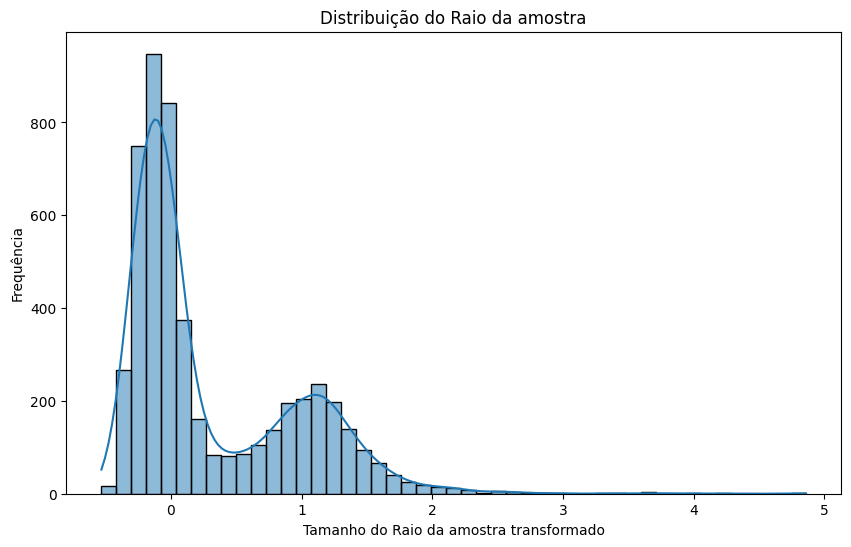

In [40]:
plt.figure(figsize=(10, 6))
sns.histplot(df_normalized['koi_prad'], kde=True)
plt.title('Distribuição do Raio da amostra')
plt.xlabel('Tamanho do Raio da amostra transformado')
plt.ylabel('Frequência')
plt.show()

O histograma do *atributo koi_prad* após a aplicação do scaler mostra a forma de distribuição original, mas os valores estão num intervalo menor.

# Aplicando o modelo (Random Forest)

## Treinamento
Não houve necessidade de balanceamento no pré-processamento dos dados devido ao fato deste algoritmo lidar bem com conjuntos de dados desbalanceados, principalmente com o parâmetro class_weight configurado para *balanced*.

In [41]:
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train_robust, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Predição

In [42]:
y_pred = model.predict(X_test_robust)

## Resultados

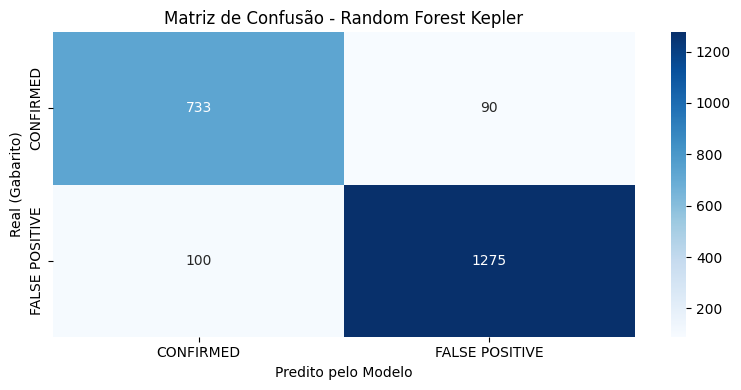

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['CONFIRMED', 'FALSE POSITIVE'], yticklabels=['CONFIRMED', 'FALSE POSITIVE'])

plt.xlabel('Predito pelo Modelo')
plt.ylabel('Real (Gabarito)')
plt.title('Matriz de Confusão - Random Forest Kepler')

plt.tight_layout()
plt.show()

In [44]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


Relatório de Classificação:
                precision    recall  f1-score   support

     CONFIRMED       0.88      0.89      0.89       823
FALSE POSITIVE       0.93      0.93      0.93      1375

      accuracy                           0.91      2198
     macro avg       0.91      0.91      0.91      2198
  weighted avg       0.91      0.91      0.91      2198



De acordo com a matriz de confusão e com o relatório de classificação foi possível obter excelentes resultados (Ex. F1-Score de 0.91) para um treinamento simples e sem muitos artifícios, o que formaria uma ótima baseline para treinar outros tipos de modelo e outras técnicas.

# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1
**Existe um limiar de raio acima do qual o número de planetas confirmados cai drasticamente**

A hipótese número 1 é validada pela clara distinção nas frequências observadas no histograma. Os **planetas confirmados** apresentam uma distribuição unimodal que após o limiar de tamanho planetário cai drasticamente, enquanto os **falsos positivos** possuem uma disposição bimodal mais espalhada por toda a área de plotagem. O Boxplot reforça essa distinção mostrando que os **objetos confirmados** tem medidas inferiores aos **falsos positivos**.

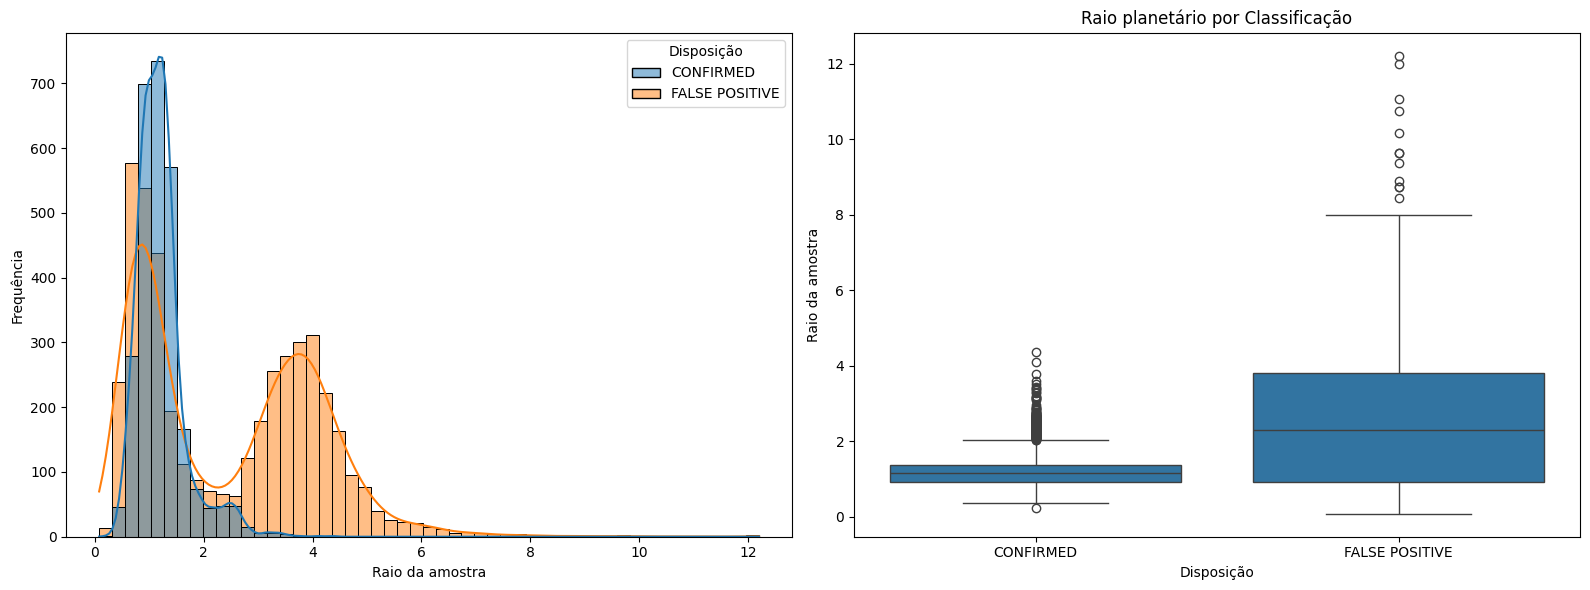

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df, x='koi_prad', kde=True, hue='koi_disposition', ax=axes[0])
axes[0].set_xlabel('Raio da amostra')
axes[0].set_ylabel('Frequência')

sns.move_legend(axes[0], "upper right", title='Disposição')

sns.boxplot(x='koi_disposition', y='koi_prad', data=df, ax=axes[1])
axes[1].set_title('Raio planetário por Classificação')
axes[1].set_xlabel('Disposição')
axes[1].set_ylabel('Raio da amostra')

plt.tight_layout()
plt.show()

## Hipótese 2
**A profundidade do trânsito impacta na classificação do objeto**

A hipótese é corroborada na análise gráfica do dataset KOI. No histograma a **profundidade do trânsito** acontece em uma distribuição unimodal numa região bem específica do gráfico, já os **falsos positivos** assumem uma alta variância. No gráfico boxplot podemos perceber a diferença clara na distribuição dos quartis, onde os **falsos positivos** possuem valores muito mais extremos extrapolando os limites físicos do trânsito planetário.

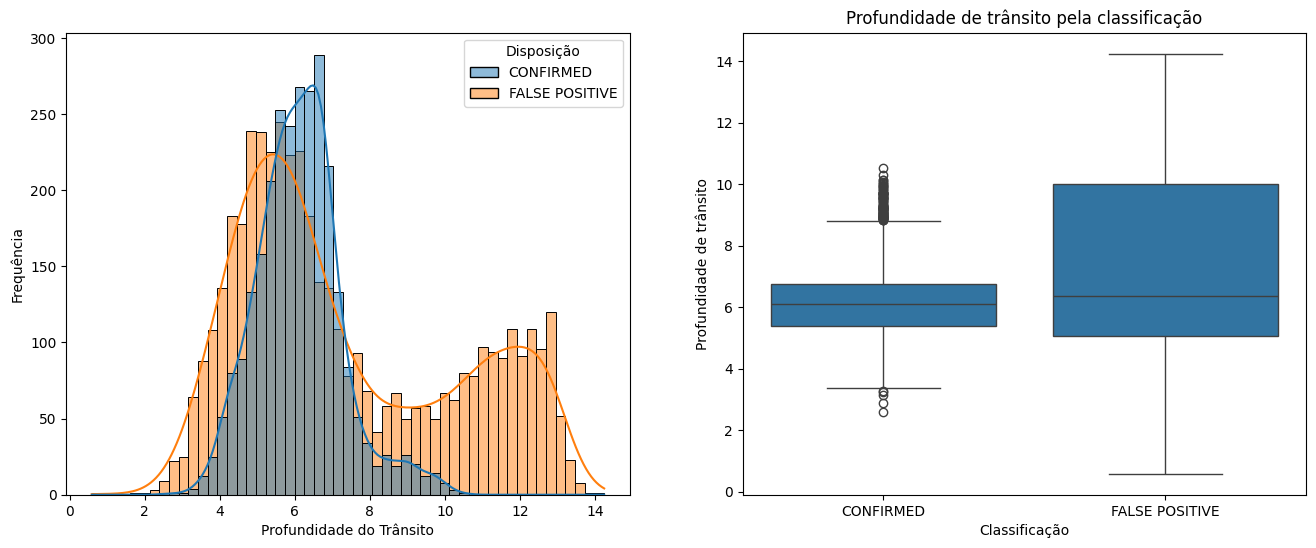

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df, x='koi_depth', kde=True, hue='koi_disposition', ax=axes[0])
axes[0].set_xlabel('Profundidade do Trânsito')
axes[0].set_ylabel('Frequência')
sns.move_legend(axes[0], "upper right", title='Disposição')

sns.boxplot(x='koi_disposition', y='koi_depth', data=df, ax=axes[1])
axes[1].set_title('Profundidade de trânsito pela classificação')
axes[1].set_xlabel('Classificação')
axes[1].set_ylabel('Profundidade de trânsito')
plt.show()

## Hipótese 3
**Existe um 'limite térmico' acima do qual a probabilidade de um objeto ser classificado como Falso Positivo aumenta drasticamente**

Os gráficos demonstram claramente um limite superior em torno de 2000K, onde o número de **planetas confirmados** passa a ser quase inexistente. Já os valores dos **falsos positivos** possuem valores muito mais extremos, em alguns casos passando de 10000K.

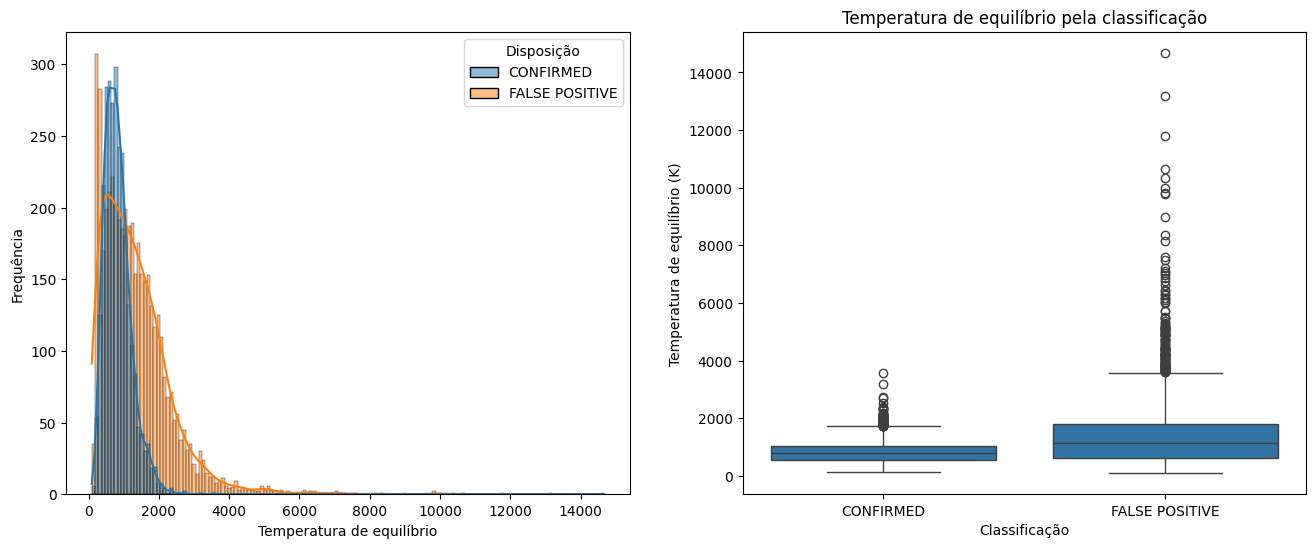

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df, x='koi_teq', kde=True, hue='koi_disposition', ax=axes[0])
axes[0].set_xlabel('Temperatura de equilíbrio')
axes[0].set_ylabel('Frequência')
sns.move_legend(axes[0], "upper right", title='Disposição')

sns.boxplot(x='koi_disposition', y='koi_teq', data=df, ax=axes[1])
axes[1].set_title('Temperatura de equilíbrio pela classificação')
axes[1].set_xlabel('Classificação')
axes[1].set_ylabel('Temperatura de equilíbrio (K)')
plt.show()

# Conclusão
O estudo do dataset KOI demonstrou ser uma ferramenta poderosa para a compreensão do comportamento de exoplanetas e das características de trânsitos além do nosso Sistema Solar. Este esforço é de suma importância, visto que a confirmação de exoplanetas ainda depende de intensa intervenção manual, o que limita a velocidade de novas descobertas.

Na etapa de pré-processamento, foram aplicadas transformações essenciais para o treinamento de um modelo de classificação (Random Forest), que apresentou um desempenho satisfatório com 91% de acurácia, servindo como um sólido baseline para futuras otimizações. Por fim, a validação das três hipóteses levantadas confirmou que variáveis como raio, profundidade de trânsito e temperatura de equilíbrio são os pilares fundamentais para distinguir planetas reais de falsos positivos astronômicos. 

# Próximos passos
Para trabalhos futuros, sugere-se o teste de algoritmos de Deep Learning ou o ajuste fino dos parâmetros para elevar ainda mais o desempenho da predição dos dados.